In [72]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import statsmodels.formula.api as fsm
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
Auto = load_data("Auto")
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


# Question 8
This question involves the use of simple linear regression on the Auto data set.

Use the `sm.OLS()` function to perform a simple linear regression with mpg as the response and horsepower as the predictor. Use the summarize() function to print the results.

In [73]:
X = pd.DataFrame({'intercept': np.ones(Auto.shape[0]),
                  'horsepower': Auto['horsepower']})
y = Auto['mpg']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


(a) Comment on the output. For example:
i. Is there a relationship between the predictor and the re- sponse?

*yep*

ii. How strong is the relationship between the predictor and the response?

*For every unit of horsepower, there is a 15% decrement in mpg.*

iii. Is the relationship between the predictor and the response positive or negative?

*negative*

iv. What is the predicted mpg associated with a horsepower of 98? What are the associated 95 % confidence and prediction intervals?

In [74]:
new_predictions = results.get_prediction(X);
oneCol = MS(['horsepower'])
X2 = oneCol.fit_transform(Auto)

new_df = pd.DataFrame({'horsepower':[98]})
newX = oneCol.transform(new_df)
newX
specific_prediction = results.get_prediction(newX)
specific_prediction.predicted_mean

array([24.46707715])

In [75]:
specific_prediction.conf_int(alpha=0.05)
specific_prediction.conf_int(obs=True, alpha=0.05)

array([[14.80939607, 34.12475823]])

(b) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.

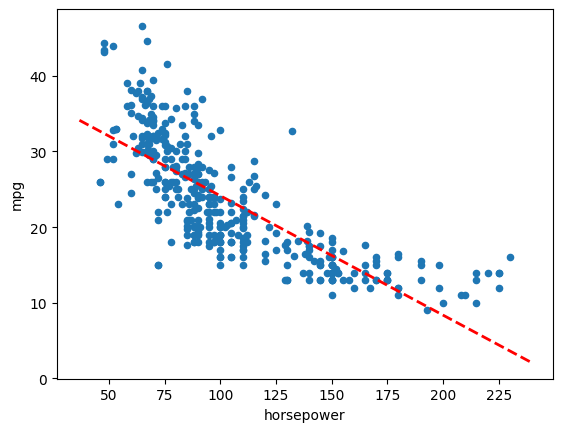

In [76]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

ax = Auto.plot.scatter('horsepower', 'mpg')
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=2
       )

(c) Produce some of diagnostic plots of the least squares regression fit as described in the lab. Comment on any problems you see with the fit.

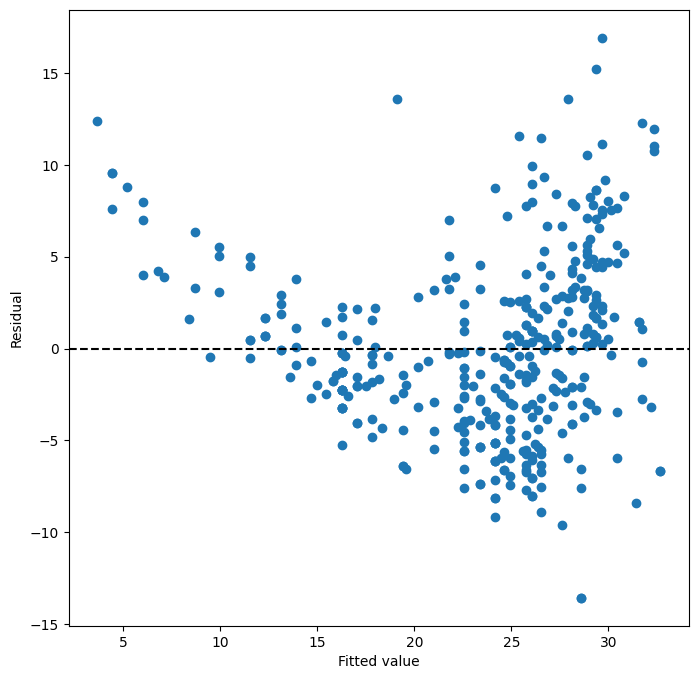

In [77]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

*I notice that there is strong evidence of non-linearity in the data due to a U-shape in the residual graph*

115

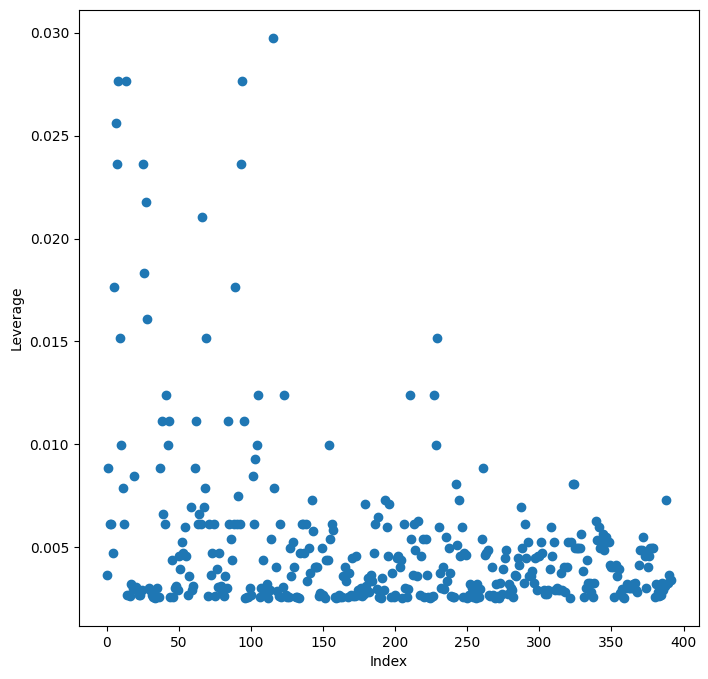

In [78]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

*I notice that there are several high-leverage points on the Lf of the graph*

# Question 9
This question involves the use of multiple linear regression on the Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables in the data set.

In [79]:
variables = Auto.columns

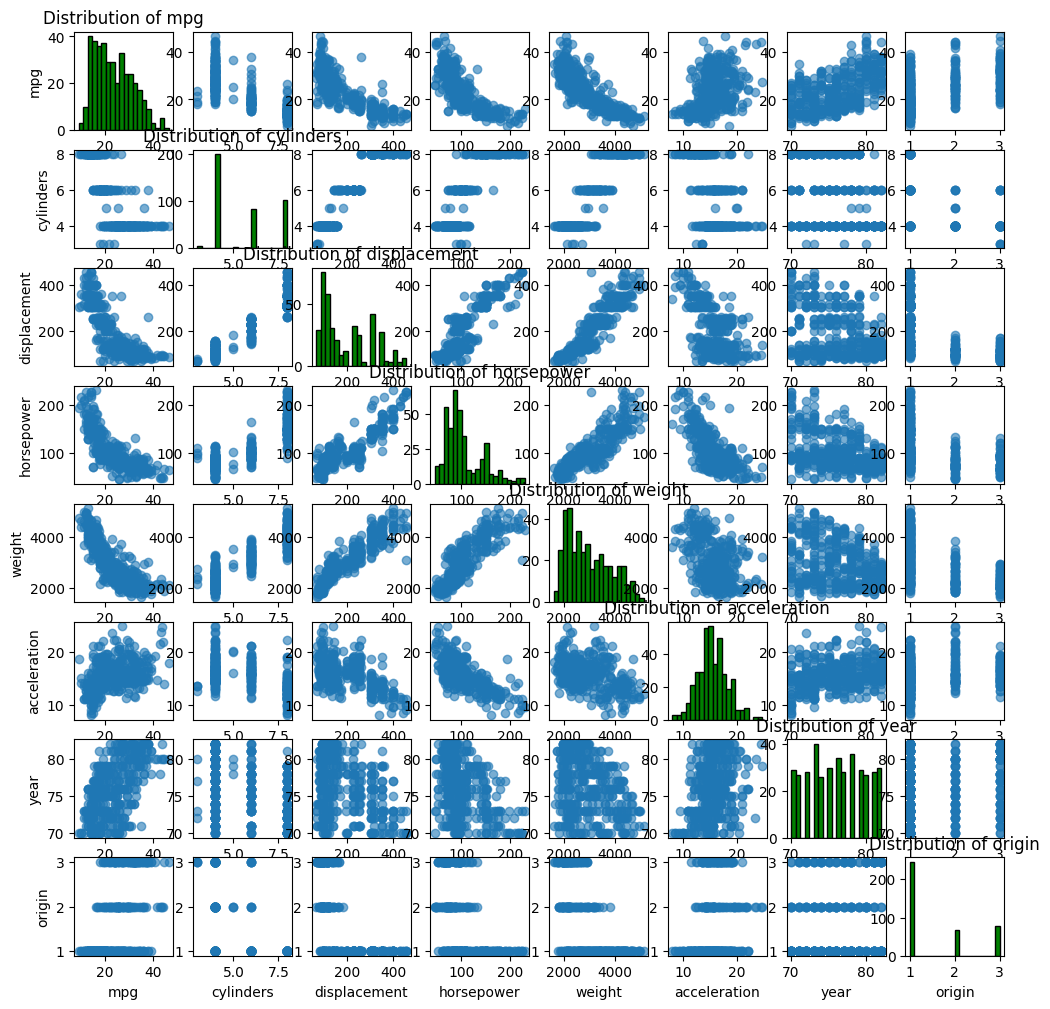

In [80]:
# Create a p x p matrix of subplots

def plot_all_scatterplots(data, numOfVariables):
    """'data' should be in form: ModelSpec(CsvData.columns).fit_transform(CsvData)"""
    fig, axes = subplots(numOfVariables, numOfVariables, figsize=(12, 12))
    # Plot scatterplots
    for i in range(numOfVariables):
        for j in range(numOfVariables):
            if i == j:
                # Plot histograms on the diagonal
                axes[i, j].hist(data[variables[i]], bins=20, color='green', edgecolor='black')
                axes[i, j].set_title(f'Distribution of {variables[i]}')
            else:
                # Plot scatterplots off the diagonal
                axes[i, j].scatter(data[variables[j]], data[variables[i]], alpha=0.6)
            # Set labels
            if i == numOfVariables - 1:
                axes[i, j].set_xlabel(variables[j])
            if j == 0:
                axes[i, j].set_ylabel(variables[i])

X = MS(variables).fit_transform(Auto)
p = len(variables)
plot_all_scatterplots(X, p)


# Adjust layout
#plt.tight_layout()
#plt.show()

(b) Compute the matrix of correlations between the variables using the `DataFrame.corr()` method.

In [81]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


(c) Use the `sm.OLS()` function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the `summarize()` function to print the results. 

In [107]:
#minus_mpg = Auto.columns.drop(['mpg'])
#Xmmpg = MS(minus_mpg).fit_transform(Auto)
#model1 = sm.OLS(y, Xmmpg)
#summarize(model1.fit())

def createModel(dataFrame, responseVariable):
    """dataFrame: pd.DataFrame
    responseVariable: string"""
    y = dataFrame[responseVariable]
    variables_less_response = dataFrame.columns.drop([responseVariable])
    dfMinusResponse = MS(variables_less_response).fit_transform(dataFrame)
    model = sm.OLS(y, dfMinusResponse)
    return model

mpgModel = createModel(Auto, 'mpg')
mpgResults = mpgModel.fit()
#summarize(mpgResults)
mpgResults.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 08 Aug 2024   Prob (F-statistic):          2.04e-139
Time:                        07:25:42   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [108]:
noDisplacementData = Auto.columns.drop(['acceleration'])

Xnd = MS(noDisplacementData).fit_transform(Auto)
ndModel = sm.OLS(y, Xnd)
ndModel.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.909e+27
Date:                Thu, 08 Aug 2024   Prob (F-statistic):               0.00
Time:                        07:39:43   Log-Likelihood:                 10418.
No. Observations:                 392   AIC:                        -2.082e+04
Df Residuals:                     384   BIC:                        -2.079e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept    -5.684e-13   8.97e-13     -0.634      0.527   -2.33e-12    1.19e-12
mpg              1.0000   1.08e-14    9.3e+13      0.000       1.000       1.000
cylinders    -7.816e-14   6.83e-14     -1.144      0.253   -2.12e-13    5.61e-14
displacement  5.135e-16   1.59e-15      0.323      0.747   -2.61e-15    3.64e-15
horsepower    1.318e-16    2.3e-15      0.057      0.954   -4.39e-15    4.66e-15
weight         8.89e-18   1.38e-16      0.064      0.949   -2.62e-16     2.8e-16
year          7.494e-16   1.34e-14      0.056      0.955   -2.56e-14    2.71e-14
origin       -1.443e-15   6.06e-14     -0.024      0.981   -1.21e-13    1.18e-13
==============================================================================
Omnibus:                     1025.495   Durbin-Watson:                   0.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.564
Skew:                           0.365   Prob(JB):                     4.23e-09
Kurtosis:                       1.648   Cond. No.                     7.86e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.86e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Comment on the output. For instance:

- (i) Is there a relationship between the predictors and the response? Use the `anova_lm()` function from statsmodels to answer this question.

In [83]:
def createModelWithFormulaApi(data, response):
    predictors = data.columns.drop([response])
    formula = ' + '.join(predictors)
    formula_model = fsm.ols(f'{response} ~ {formula}', data=data)
    return formula_model

formulaMpgModel = createModelWithFormulaApi(Auto, 'mpg')

anova_lm(formulaMpgModel.fit())

,df,sum_sq,mean_sq,F,PR(>F)
cylinders,1.0,14403.083079,14403.083079,1300.683788,2.319511e-125
displacement,1.0,1073.344025,1073.344025,96.929329,1.530906e-20
horsepower,1.0,403.408069,403.408069,36.430140,3.731128e-09
weight,1.0,975.724953,975.724953,88.113748,5.544461e-19
acceleration,1.0,0.966071,0.966071,0.087242,7.678728e-01
year,1.0,2419.120249,2419.120249,218.460900,1.875281e-39
origin,1.0,291.134494,291.134494,26.291171,4.665681e-07
Residual,384.0,4252.212530,11.073470,NaN,NaN


- (ii) Which predictors appear to have a statistically significant relationship to the response?

*Based on the F-statistics, it seems that 'cylinders' and 'year' have the clearest relationship to the response ('mpg'), while 'acceleration' and 'horsepower' have the least clear relationship*

- (iii) What does the coefficient for the 'year' variable suggest?

*Every increase in unit of 'mpg' is associated with .75 unit increase of 'year'*

(d)) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

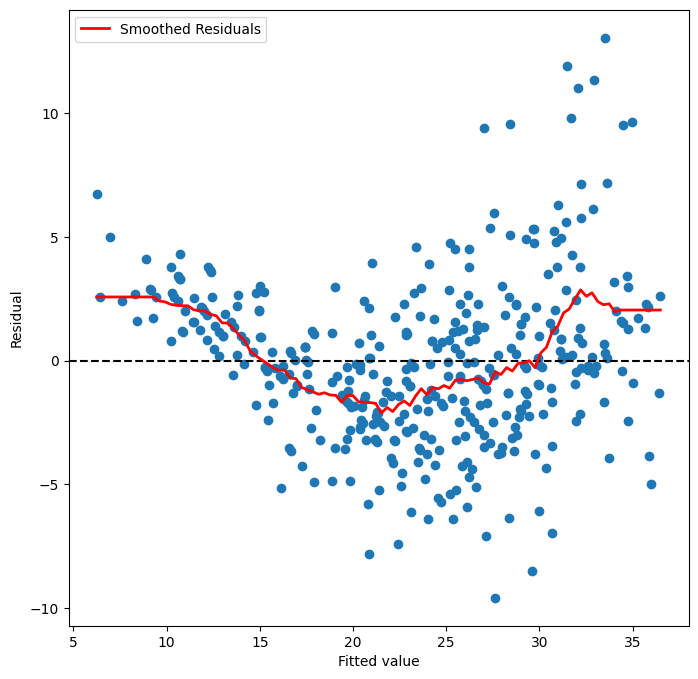

In [88]:
def plot_residuals_with_knn_trendline(axes, resultsObject, n_neighbors = 40):
    axes.scatter(resultsObject.fittedvalues, resultsObject.resid)
    axes.set_xlabel('Fitted value')
    axes.set_ylabel('Residual')
    axes.axhline(0, c = 'k', ls = '--')

    # Fit KNN regressor to the residuals
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    fitted_values = resultsObject.fittedvalues.values.reshape(-1, 1)
    residuals = resultsObject.resid.values
    knn.fit(fitted_values, residuals)
    
    # Predict smoothed residuals
    x_values = np.linspace(fitted_values.min(), fitted_values.max(), 100).reshape(-1, 1)
    smoothed_residuals = knn.predict(x_values)
    
    # Plot the smoothed residuals line
    axes.plot(x_values, smoothed_residuals, color='red', linestyle='-', linewidth=2, label='Smoothed Residuals')
    
    # Add legend
    axes.legend()

ax = subplots(figsize=(8,8))[1]
plot_residuals_with_knn_trendline(ax, mpgResults)

13

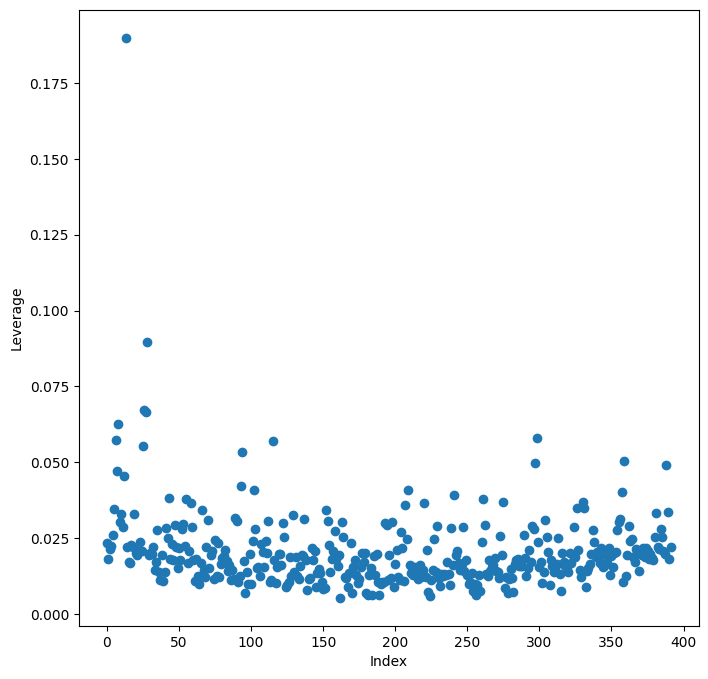

In [92]:
def plot_leverage_plot(axes, resultsObject, nPoints):
    """nPoints == number of datapoints, from the fitted + transformed
    ModelSpec object
    returns the index of the datapoint with highest leverage"""
    infl = resultsObject.get_influence()
    ax.scatter(np.arange(nPoints), infl.hat_matrix_diag)
    ax.set_xlabel('Index')
    ax.set_ylabel('Leverage')
    return np.argmax(infl.hat_matrix_diag)

nPoints = X.shape[0]
ax = subplots(figsize=(8,8))[1]
plot_leverage_plot(ax, mpgResults, nPoints)

In [98]:
VIFvals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif': VIFvals}, index=X.columns[1:])
vif

,vif
mpg,5.601553
cylinders,10.802663
displacement,22.235364
horsepower,9.982839
weight,13.611870
acceleration,2.630350
year,1.948277
origin,1.893736


(e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [94]:
Xi = MS(['year', 'origin', ('displacement', 'weight'), ('acceleration', 'cylinders')]).fit_transform(Auto)
interactionModel = sm.OLS(y, Xi)
summarize(interactionModel.fit())

,coef,std err,t,P>|t|
intercept,-26.879300,4.535000e+00,-5.927,0.0
year,0.747100,5.800000e-02,12.974,0.0
origin,1.528600,3.020000e-01,5.069,0.0
displacement:weight,-0.000007,5.690000e-07,-12.577,0.0
acceleration:cylinders,-0.049800,1.200000e-02,-4.048,0.0


(f) Try a few different transformations of the variables, such as log(X), √X, X2. Comment on your findings.

In [97]:
Xp = MS([poly('horsepower', degree=2), 'year']).fit_transform(Auto)
modelPoly = sm.OLS(y, Xp)
resultsPoly = modelPoly.fit()
#summarize(resultsPoly)





,coef,std err,t,P>|t|
intercept,-29.2975,4.264,-6.871,0.0
"poly(horsepower, degree=2)[0]",-99.0845,4.079,-24.291,0.0
"poly(horsepower, degree=2)[1]",46.5061,3.713,12.525,0.0
year,0.6942,0.056,12.382,0.0
